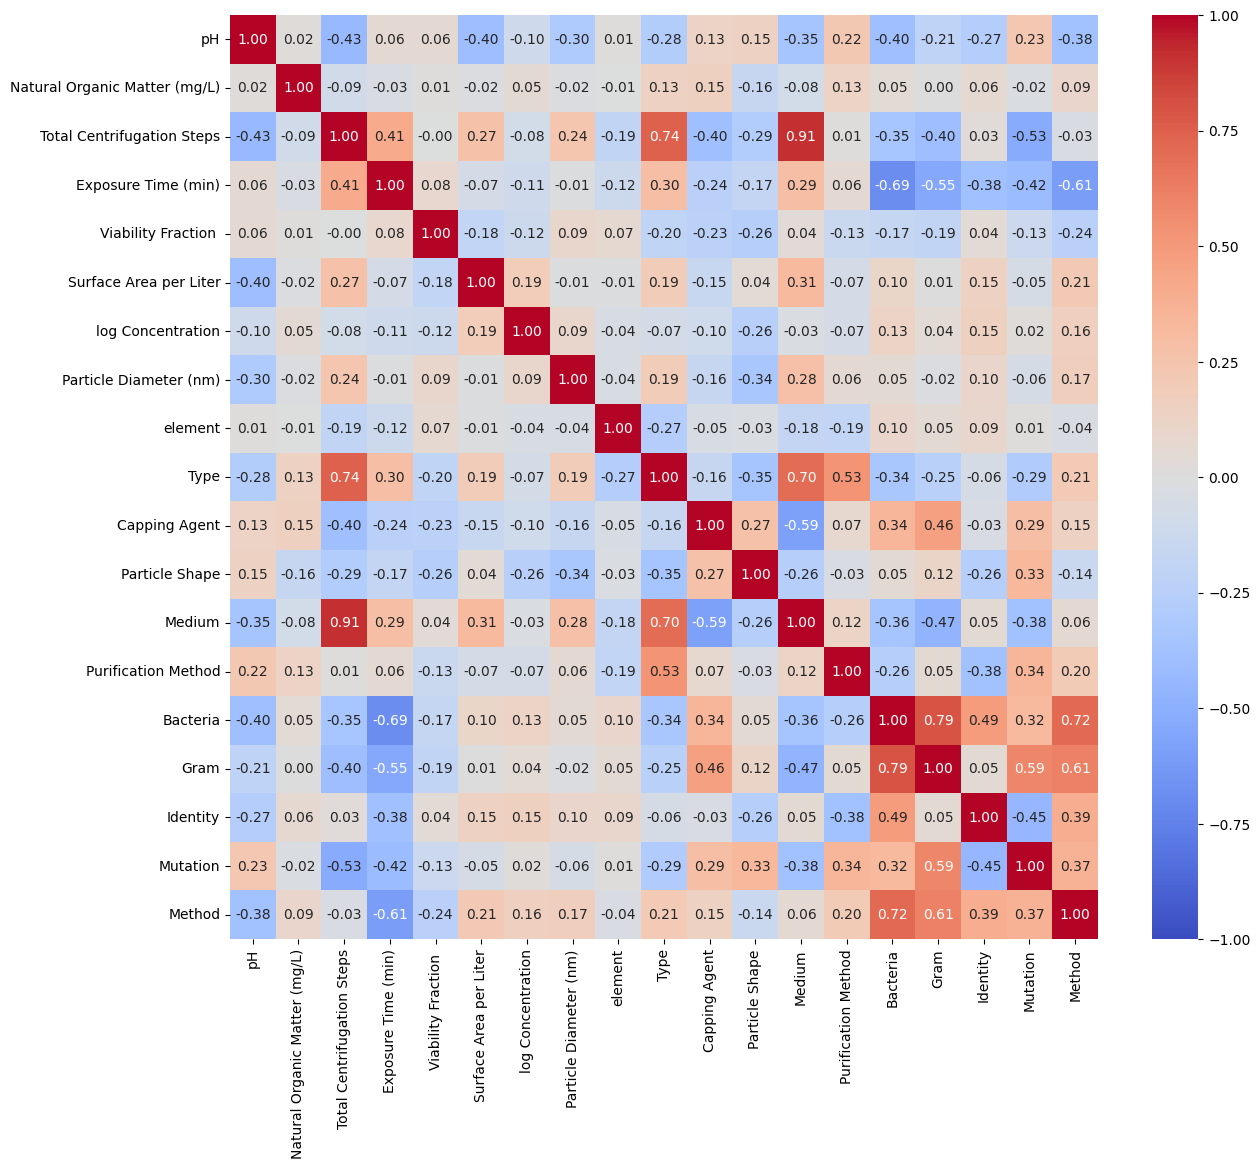

In [1]:
import pandas as pd
import numpy as np
import random
import torch
import seaborn as sns
import matplotlib.pyplot as plt

# Set seed for reproducibility
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# 1. Data Preparation
# ------------------------------
def load_CSN_data():
    csv_path = '../../Master_List_LCPLCP.csv'
    return pd.read_csv(csv_path)

# Load and preprocess the dataset
CSN = load_CSN_data()

# Drop unused columns
CSN = CSN.drop(['Example ID', 'Source', 'Figure ID', 'Data Provider', 'PI',
                'Date Received', 'Data Measurment Published', 'Prior Exposure', 'Comments', 'Error'], axis=1)

# Apply one-hot encoding to categorical columns
CSN_prepared = pd.get_dummies(CSN, dtype=int)

# Create new features based on numerical columns
CSN_prepared['Surface Area per Liter'] = CSN_prepared['Surface Area (NMC) (m2/g)'] * CSN_prepared['Concentration (mg/L)']
CSN_prepared = CSN_prepared.drop(['Surface Area (NMC) (m2/g)'], axis=1)
CSN_prepared['log Concentration'] = np.log10(CSN_prepared['Concentration (mg/L)'] + 1e-9)
CSN_prepared = CSN_prepared.drop(['Concentration (mg/L)'], axis=1)

# ----- Group 0: Element -----
# Aggregate the element columns into one single column "element"
element_cols = ['Carbon', 'Nitrogen', 'Phosphorus', 'Hydrogen', 'Titanium', 'Gold',
                'Lithium', 'Nickel', 'Cobalt', 'Manganese', 'Oxygen', 'Cadmium',
                'Selenium', 'Sulfur', 'Silicon', 'Platinum', 'Zinc']
CSN_prepared['element'] = CSN_prepared[element_cols].sum(axis=1)
CSN_prepared = CSN_prepared.drop(columns=element_cols)

# Make a working copy for merging related features
df = CSN_prepared.copy()

# ----- Group 1: Particle Diameter -----
# Merge three dimensions into one value (e.g., the mean diameter)
diameter_cols = ['Particle Diameter Dimension 1 (nm)', 
                 'Particle Diameter Dimension 2 (nm)', 
                 'Particle Diameter Dimension 3 (nm)']
df['Particle Diameter (nm)'] = df[diameter_cols].mean(axis=1)
df = df.drop(columns=diameter_cols)

# ----- Group 2: Type -----
type_cols = [col for col in df.columns if col.startswith('Type_')]
def get_type(row):
    active = row[type_cols]
    if active.sum() == 0:
        return np.nan
    else:
        return active.idxmax().replace('Type_', '')
df['Type'] = df.apply(get_type, axis=1)
df = df.drop(columns=type_cols)

# ----- Group 3: Capping Agent -----
cap_cols = [col for col in df.columns if col.startswith('Capping Agent_')]
def get_capping_agent(row):
    active = row[cap_cols]
    if active.sum() == 0:
        return np.nan
    else:
        return active.idxmax().replace('Capping Agent_', '')
df['Capping Agent'] = df.apply(get_capping_agent, axis=1)
df = df.drop(columns=cap_cols)

# ----- Group 4: Particle Shape -----
shape_cols = [col for col in df.columns if col.startswith('Particle Shape_')]
def get_shape(row):
    active = row[shape_cols]
    if active.sum() == 0:
        return np.nan
    else:
        return active.idxmax().replace('Particle Shape_', '')
df['Particle Shape'] = df.apply(get_shape, axis=1)
df = df.drop(columns=shape_cols)

# ----- Group 5: Medium -----
medium_cols = [col for col in df.columns if col.startswith('Medium_')]
def get_medium(row):
    active = row[medium_cols]
    if active.sum() == 0:
        return np.nan
    else:
        return active.idxmax().replace('Medium_', '')
df['Medium'] = df.apply(get_medium, axis=1)
df = df.drop(columns=medium_cols)

# ----- Group 6: Purification Method -----
purification_cols = [col for col in df.columns if col.startswith('Purification Method_')]
def get_purification_method(row):
    active = row[purification_cols]
    if active.sum() == 0:
        return np.nan
    else:
        return active.idxmax().replace('Purification Method_', '')
df['Purification Method'] = df.apply(get_purification_method, axis=1)
df = df.drop(columns=purification_cols)

# ----- Group 7: Bacteria -----
def get_bacteria(row):
    if row['Bacteria_Yes'] == 1:
        return 'Yes'
    elif row['Bacteria_No'] == 1:
        return 'No'
    else:
        return np.nan
df['Bacteria'] = df.apply(get_bacteria, axis=1)
df = df.drop(columns=['Bacteria_No', 'Bacteria_Yes'])

# ----- Group 8: Gram -----
def get_gram(row):
    if row['Gram_Negative'] == 1:
        return 'Negative'
    elif row['Gram_Positive'] == 1:
        return 'Positive'
    else:
        return np.nan
df['Gram'] = df.apply(get_gram, axis=1)
df = df.drop(columns=['Gram_Negative', 'Gram_Positive'])

# ----- Group 9: Identity -----
identity_cols = [col for col in df.columns if col.startswith('Identity ')]
def get_identity(row):
    active = row[identity_cols]
    if active.sum() == 0:
        return np.nan
    else:
        return active.idxmax().replace('Identity _', '').strip()
df['Identity'] = df.apply(get_identity, axis=1)
df = df.drop(columns=identity_cols)

# ----- Group 10: Mutation -----
mutation_cols = [col for col in df.columns if col.startswith('Mutation_')]
def get_mutation(row):
    active = row[mutation_cols]
    if active.sum() == 0:
        return np.nan
    else:
        return active.idxmax().replace('Mutation_', '')
df['Mutation'] = df.apply(get_mutation, axis=1)
df = df.drop(columns=mutation_cols)

# ----- Group 11: Method -----
method_cols = [col for col in df.columns if col.startswith('Method_')]
def get_method(row):
    active = row[method_cols]
    if active.sum() == 0:
        return np.nan
    else:
        return active.idxmax().replace('Method_', '')
df['Method'] = df.apply(get_method, axis=1)
df = df.drop(columns=method_cols)

# At this point, df contains:
# - Merged numeric features: 'Particle Diameter (nm)', 'pH', 'Natural Organic Matter (mg/L)',
#   'Total Centrifugation Steps', 'Exposure Time (min)', 'Viability Fraction ',
#   'Surface Area per Liter', 'log Concentration', and 'element'
# - Grouped categorical features: 'Type', 'Capping Agent', 'Particle Shape', 'Medium',
#   'Purification Method', 'Bacteria', 'Gram', 'Identity', 'Mutation', 'Method'

# ------------------------------
# 2. Prepare Data for Correlation Analysis
# ------------------------------
# For correlation heatmap, we need numeric data.
# Convert categorical group indicators to numeric using label encoding.
group_categorical = ['Type', 'Capping Agent', 'Particle Shape', 'Medium', 
                     'Purification Method', 'Bacteria', 'Gram', 'Identity', 
                     'Mutation', 'Method']

for col in group_categorical:
    df[col] = pd.Categorical(df[col]).codes

# Define the list of numeric columns including both original numeric features and converted group indicators.
numeric_cols = [
    'pH',
    'Natural Organic Matter (mg/L)',
    'Total Centrifugation Steps',
    'Exposure Time (min)',
    'Viability Fraction ',
    'Surface Area per Liter',
    'log Concentration',
    'Particle Diameter (nm)',
    'element'  # Include the element group here
] + group_categorical

# Compute the correlation matrix on the selected numeric columns
corr_matrix = df[numeric_cols].corr()

# ------------------------------
# 3. Plot Correlation Heatmap
# ------------------------------
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
#plt.title("Correlation Heatmap of All CSN Data Groups and Numeric Features")
plt.savefig("CSN_Correlation_Heatmap.pdf", dpi=300, bbox_inches='tight')  # Save the figure
plt.show()


In [7]:
CSN.columns

Index(['Type', 'Carbon', 'Nitrogen', 'Phosphorus', 'Hydrogen', 'Titanium',
       'Gold', 'Lithium', 'Nickel', 'Cobalt', 'Manganese', 'Oxygen', 'Cadmium',
       'Selenium', 'Sulfur', 'Silicon', 'Platinum', 'Zinc',
       'Total Comp Knowledge', 'Particle Diameter Dimension 1 (nm)',
       'Particle Diameter Dimension 2 (nm)',
       'Particle Diameter Dimension 3 (nm)', 'Capping Agent', 'Particle Shape',
       'Concentration (mg/L)', 'Surface Area (NMC) (m2/g)', 'pH', 'Medium',
       'Natural Organic Matter (mg/L)', 'Purification Method',
       'Total Centrifugation Steps', 'Exposure Time (min)', 'Bacteria', 'Gram',
       'Identity ', 'Mutation', 'Method', 'Viability Fraction '],
      dtype='object')

In [9]:
df.columns

Index(['Carbon', 'Nitrogen', 'Phosphorus', 'Hydrogen', 'Titanium', 'Gold',
       'Lithium', 'Nickel', 'Cobalt', 'Manganese', 'Oxygen', 'Cadmium',
       'Selenium', 'Sulfur', 'Silicon', 'Platinum', 'Zinc', 'pH',
       'Natural Organic Matter (mg/L)', 'Total Centrifugation Steps',
       'Exposure Time (min)', 'Viability Fraction ', 'Total Comp Knowledge_F',
       'Total Comp Knowledge_T', 'Surface Area per Liter', 'log Concentration',
       'Particle Diameter (nm)', 'Type', 'Capping Agent', 'Particle Shape',
       'Medium', 'Purification Method', 'Bacteria', 'Gram', 'Identity',
       'Mutation', 'Method'],
      dtype='object')